In [1]:
from ravex import MultiPlanetSystem, maroonx_serval_error, plot_detection_growth_strict, n_at_sigma
import numpy as np
import astropy.units as u
import astropy.time as t
import matplotlib.pyplot as plt

In [2]:
# Define the host star mass
mass_star = 0.2 * u.solMass

# Define a single planet
planet1 = {
    "mass": 5.0 * u.earthMass,
    "time_periastron": t.Time("2025-06-21T05:48:29.000", format="isot", scale="utc"),
    "inclination": 90.0 * u.deg,
    "argument_periapse": 90.0 * u.deg,
    "eccentricity": 0.0,
    "orbital_period": 13 * u.day,
}

# Build the planetary system
system = MultiPlanetSystem(mass_star, [planet1])

In [3]:
# Build a dense and regular time grid over the same observing baseline
n_model = 10000
# Define the observing baseline
start_time = t.Time("2026-07-01T00:00:00", format="isot", scale="utc")
span_days = 100

time_grid = t.Time(
    start_time.jd + np.linspace(0, span_days, n_model),
    format="jd",
    scale="utc"
)

# Compute the noiseless RV model
jd_model, rv_model, phases_model, phased_model = system.get_rvs(time_grid)

In [4]:
rv_max = np.max(rv_model)
rv_min = np.min(rv_model)
K_est = 0.5 * (rv_max - rv_min)

print(f"Estimated semi-amplitude K: {K_est:.3f} m/s")

Estimated semi-amplitude K: 3.976 m/s


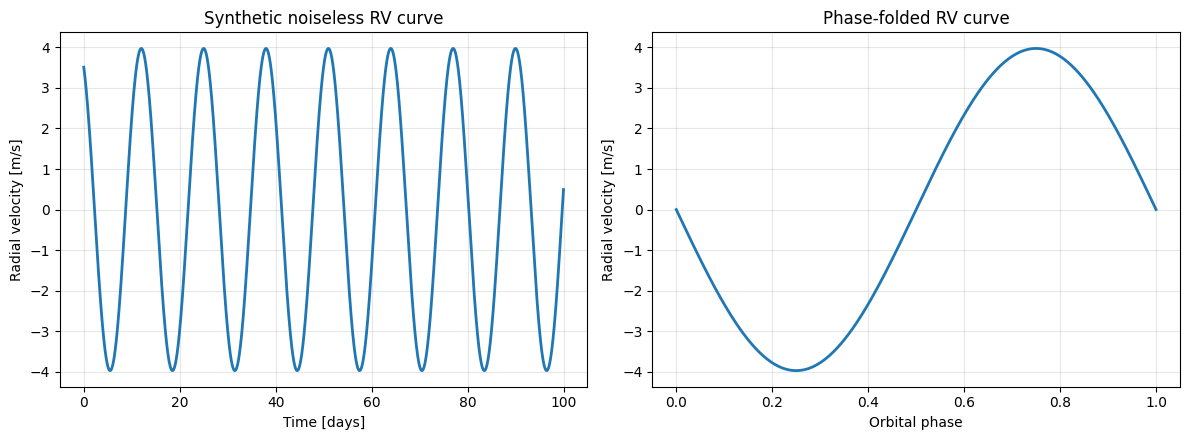

In [5]:
# Plot the theoretical noiseless RV curve in time and phase
time_days = jd_model - jd_model[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left panel: RV as a function of time
axes[0].plot(time_days, rv_model, lw=2)
axes[0].set_xlabel("Time [days]")
axes[0].set_ylabel("Radial velocity [m/s]")
axes[0].set_title("Synthetic noiseless RV curve")
axes[0].grid(alpha=0.3)

# Right panel: RV as a function of orbital phase
axes[1].plot(phased_model["p0"]["phase"], phased_model["p0"]["rv"], lw=2)
axes[1].set_xlabel("Orbital phase")
axes[1].set_ylabel("Radial velocity [m/s]")
axes[1].set_title("Phase-folded RV curve")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [6]:
# MAROON-X input from the ETC
snr_peak_red = 77   # example value from the ETC
snr_peak_blue = 24.5   # in this example the blue contribution is very low

arm1 = "red"
arm2 = "blue"

# Estimated intrinsic SERVAL RV uncertainty for MAROON-X
sigma_maroonx_red = maroonx_serval_error(
    snr_peak=snr_peak_red,
    spectral_type="M4.5",  
    arm=arm1
)

sigma_maroonx_blue = maroonx_serval_error(
    snr_peak=snr_peak_blue,
    spectral_type="M4.5",   
    arm=arm2
)

# Assumed stellar jitter. For M quiet stars, the jitter is in the range of 2-3m/s (Ruh et al. 2024)
sigma_jitter = 2.5  # m/s

# Total per-measurement uncertainty
sigma_eff_maroonx_red = np.sqrt(sigma_maroonx_red**2 + sigma_jitter**2)
sigma_eff_maroonx_blue = np.sqrt(sigma_maroonx_blue**2 + sigma_jitter**2)


print(f"MAROON-X ({arm1} arm) instrumental error: {sigma_maroonx_red:.3f} m/s")
print(f"Assumed stellar jitter: {sigma_jitter:.3f} m/s")
print(f"Total RV uncertainty per measurement: {sigma_eff_maroonx_red:.3f} m/s")
print("**********")
print(f"MAROON-X ({arm2} arm) instrumental error: {sigma_maroonx_blue:.3f} m/s")
print(f"Assumed stellar jitter: {sigma_jitter:.3f} m/s")
print(f"Total RV uncertainty per measurement: {sigma_eff_maroonx_blue:.3f} m/s")

MAROON-X (red arm) instrumental error: 1.693 m/s
Assumed stellar jitter: 2.500 m/s
Total RV uncertainty per measurement: 3.019 m/s
**********
MAROON-X (blue arm) instrumental error: 3.716 m/s
Assumed stellar jitter: 2.500 m/s
Total RV uncertainty per measurement: 4.479 m/s


In [7]:
# Simulate discrete RV observations with noise
n_obs = 30
start_time = t.Time("2026-07-01T00:00:00", format="isot", scale="utc")

rng = np.random.default_rng(42)

observation_dates = system.obs_dates(
    n_obs=n_obs,
    span_days=span_days,
    date_one=start_time,
    rng=rng
)

jd_sim_red, rv_sim_red, phases_sim_red, phased_sim_red = system.get_rvs(
    observation_dates,
    noise=sigma_eff_maroonx_red * u.m / u.s,
    rng=np.random.default_rng(42)
)

jd_sim_blue, rv_sim_blue, phases_sim_blue, phased_sim_blue = system.get_rvs(
    observation_dates,
    noise=sigma_eff_maroonx_blue * u.m / u.s,
    rng=np.random.default_rng(43)
)

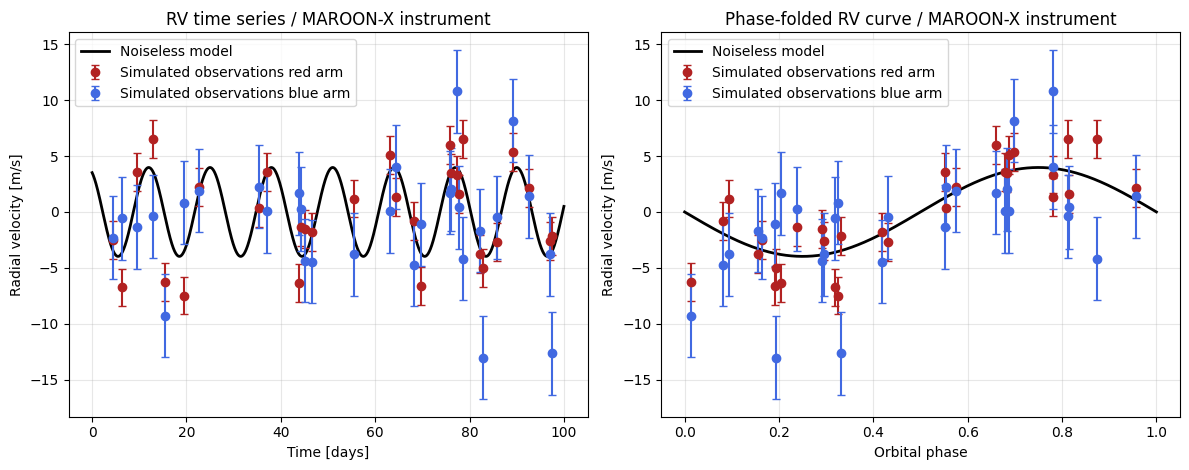

In [8]:
# Plot the noiseless model and the simulated RV observations in time and phase
time_model_days = jd_model - jd_model[0]
time_sim_days_red = jd_sim_red - jd_model[0]
time_sim_days_blue = jd_sim_blue - jd_model[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# Left panel: time series
axes[0].plot(time_model_days, rv_model, lw=2, color='black',label="Noiseless model")
axes[0].errorbar(
    time_sim_days_red,
    rv_sim_red,
    yerr=sigma_maroonx_red,
    fmt="o",
    capsize=3,
    color="firebrick",
    label="Simulated observations red arm"
)

axes[0].errorbar(
    time_sim_days_blue,
    rv_sim_blue,
    yerr=sigma_maroonx_blue,
    fmt="o",
    capsize=3,
    color="royalblue",
    label="Simulated observations blue arm"
)

axes[0].set_xlabel("Time [days]")
axes[0].set_ylabel("Radial velocity [m/s]")
axes[0].set_title("RV time series / MAROON-X instrument")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right panel: phase-folded curve
axes[1].plot(phased_model["p0"]["phase"], phased_model["p0"]["rv"], lw=2, color='black',label="Noiseless model")

axes[1].errorbar(
    phased_sim_red["p0"]["phase"],
    phased_sim_red["p0"]["rv"],
    yerr=sigma_maroonx_red,
    fmt="o",
    capsize=3,
    color="firebrick",
    label="Simulated observations red arm"
)

axes[1].errorbar(
    phased_sim_blue["p0"]["phase"],
    phased_sim_blue["p0"]["rv"],
    yerr=sigma_maroonx_blue,
    fmt="o",
    capsize=3,
    color="royalblue",
    label="Simulated observations blue arm"
)

axes[1].set_xlabel("Orbital phase")
axes[1].set_ylabel("Radial velocity [m/s]")
axes[1].set_title("Phase-folded RV curve / MAROON-X instrument")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Detection growth curve

The `detection_growth_curve_strict` function is designed to quantify how the detectability of an injected planetary signal evolves as the number of RV observations increases.

For each simulated observing campaign, the function evaluates progressively larger subsets of the data, starting from a minimum number of observations (`n_min`) and increasing up to the full dataset (`N`). At each step, it computes a generalized Lomb–Scargle periodogram and identifies the strongest recovered periodicity.

A trial contributes to the detection significance only if the strongest recovered period falls sufficiently close to the injected planetary period, within the adopted relative tolerance `tol_rel`. If this condition is not met, the detection significance for that step is set to zero.

The main outputs of this function are:

- `sigma_med`: median detection significance as a function of the number of observations,
- `sigma_mean`: mean detection significance as a function of the number of observations,
- `hit_rate`: fraction of trials in which the strongest recovered period matches the injected one within the adopted tolerance (10%),
- `N50` and `N90`: the first number of observations for which the hit rate reaches 50% and 90%, respectively.

In practice, this function is useful for visualizing **how the strength of the detection builds up as more RV measurements are accumulated**.

In [9]:
res_strict_red = system.detection_growth_curve_strict(
    planet_index=0,
    N=100,
    span_days=span_days,
    start_time=start_time,
    sigma_eff=sigma_eff_maroonx_red * u.m/u.s,
    n_iter=400,
    n_min=6,
    tol_rel=0.10,
    fap_method="baluev",
    rng_seed=42
)

print("RED")
print("N50 (hit rate):", res_strict_red["N50"])
print("N90 (hit rate):", res_strict_red["N90"])
print("n @ 3σ median:", n_at_sigma(res_strict_red, sigma_level=3.0, which="median"))
print("n @ 5σ median:", n_at_sigma(res_strict_red, sigma_level=5.0, which="median"))

RED
N50 (hit rate): 22
N90 (hit rate): 35
n @ 3σ median: {'n_cross': 42, 'idx': 36, 'sigma_at': 3.056682853831388}
n @ 5σ median: {'n_cross': 73, 'idx': 67, 'sigma_at': 5.06462708867633}


In [10]:
res_strict_blue = system.detection_growth_curve_strict(
    planet_index=0,
    N=100,
    span_days=span_days,
    start_time=start_time,
    sigma_eff=sigma_eff_maroonx_blue * u.m/u.s,
    n_iter=400,
    n_min=6,
    tol_rel=0.10,
    fap_method="baluev",
    rng_seed=43
)

print("BLUE")
print("N50 (hit rate):", res_strict_blue["N50"])
print("N90 (hit rate):", res_strict_blue["N90"])
print("n @ 3σ median:", n_at_sigma(res_strict_blue, sigma_level=3.0, which="median"))
print("n @ 5σ median:", n_at_sigma(res_strict_blue, sigma_level=5.0, which="median"))

BLUE
N50 (hit rate): 37
N90 (hit rate): 65
n @ 3σ median: {'n_cross': 79, 'idx': 73, 'sigma_at': 3.0423415760343704}
n @ 5σ median: {'n_cross': nan, 'idx': None, 'sigma_at': nan}


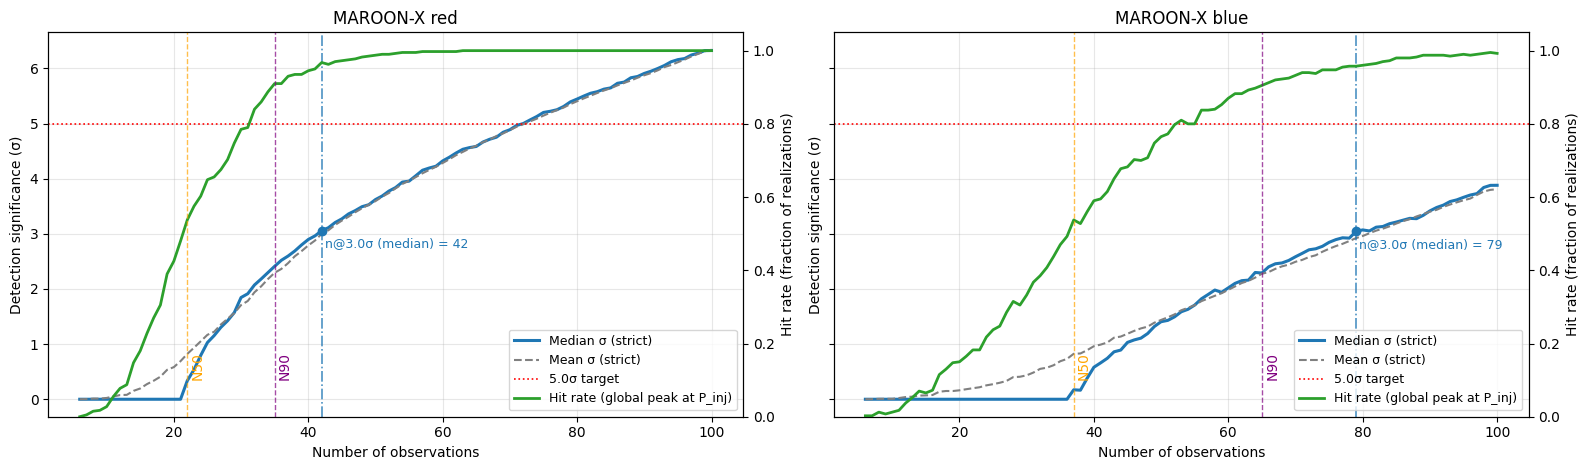

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), sharey=True)

plot_detection_growth_strict(
    res_strict_red,
    show_goal_sigma=5.0,
    mark_sigma_level=3.0,
    mark_which="median",
    ax=axes[0],
)
axes[0].set_title("MAROON-X red")

plot_detection_growth_strict(
    res_strict_blue,
    show_goal_sigma=5.0,
    mark_sigma_level=3.0,
    mark_which="median",
    ax=axes[1],
)
axes[1].set_title("MAROON-X blue")

plt.tight_layout()
plt.show()

### Interpreting the detection-growth plot

This figure shows how the detectability of the injected planet evolves as the number of observations increases. For each value of `n_obs`, many independent realizations of the observing campaign are generated, and a GLS periodogram is computed using only the first `n_obs` measurements of each realization.

The interpretation of the curves is the following:

- **Blue solid line**: median detection significance, `sigma_med`, across all realizations.  
- **Gray dashed line**: mean detection significance, `sigma_mean`, across all realizations.  
- **Green solid line**: hit rate, i.e. the fraction of realizations in which the **global peak** of the periodogram falls at the injected planet period, within the adopted tolerance.

Importantly, this is a **strict** metric. In each realization, the detection significance is only computed if the strongest peak in the periodogram is associated with the injected planet. If the global peak falls elsewhere, that realization is assigned **σ = 0**. Therefore:

- the **green curve** tells us how often the injected planet becomes the **dominant periodicity** in the periodogram;
- the **blue and gray curves** summarize the detection significance of that dominant-peak recovery across all realizations, including zeros when the planet is not the dominant signal.

The horizontal red dotted line marks the chosen detection goal (here, **5σ**). The vertical markers indicate useful milestones:

- **N50**: number of observations for which the hit rate first reaches 50%;
- **N90**: number of observations for which the hit rate first reaches 90%;
- **n@3σ (median)**: first number of observations for which the median significance reaches 3σ.

In practice, the green curve is the most direct way to identify when the injected planet starts to dominate the periodogram, while the blue and gray curves quantify how significant that recovery is.


### `detection_growth_curve_strict` vs. `detectability_tracker`

Although both functions are related to RV detectability, they answer **different questions** and should not be interpreted in the same way.

#### 1. `detection_growth_curve_strict`: how the signal builds up as observations accumulate

`detection_growth_curve_strict` is designed to show the **progressive growth** of the injected signal as more observations are added.

For each realization, the function first generates a synthetic RV campaign with a **maximum size** `N`. It then recomputes the GLS periodogram using only the first `n` observations, with `n` running from `n_min` up to `N`. In this way, the function tracks how the dominant signal evolves as the observing campaign grows.

Its main outputs are:

- `sigma_med`: median detection significance across realizations,
- `sigma_mean`: mean detection significance across realizations,
- `hit_rate`: fraction of realizations in which the global peak is associated with the injected planet,
- `N50` and `N90`: first numbers of observations for which the hit rate reaches 50% and 90%, respectively.

Importantly, this function does **not** impose a fixed detection threshold such as 3σ or 5σ internally. If a 3σ or 5σ line is shown in the figure, it is only a **visual reference** to help interpret where the median or mean significance curve crosses that level.

In short, this function answers:

> *How does the recovered significance of the injected planet grow as observations accumulate?*

#### 2. `detectability_tracker`: probability of achieving a formal detection at a chosen threshold

`detectability_tracker` is designed to answer a different question.

For each value of `N` in `n_obs_list`, the function generates many independent RV campaigns containing exactly `N` observations. It then computes a GLS periodogram for each one and checks whether:

1. the global peak falls close enough to the injected period, and  
2. the signal exceeds a user-defined detection threshold, set through `sigma_target` (for example 3σ or 5σ).

Its main outputs are:

- `p_hit`: fraction of trials in which the injected period is correctly recovered,
- `p_det`: fraction of trials in which the signal is both correctly recovered **and** significant above the required threshold,
- `N_min_90`: first value of `N` for which `p_det >= 0.90`.

So here the 3σ or 5σ threshold is **part of the detection criterion itself**, not just a visual guide.

In short, this function answers:

> *For a given number of observations, what is the probability of obtaining a formal detection above a chosen significance threshold?*

#### 3. Practical difference

A useful way to summarize the difference is:

- **`detection_growth_curve_strict`** is a **growth diagnostic**: it shows how the signal emerges as the observing sequence is progressively built up.
- **`detectability_tracker`** is a **threshold-based detectability metric**: it tells us how many observations are needed to claim a detection at a predefined level such as 3σ or 5σ.

Therefore, even if both plots may display values such as 3σ or 5σ, they do **not** mean the same thing:

- in **`detection_growth_curve_strict`**, 3σ or 5σ usually indicate where the median or mean significance curve happens to cross those levels;
- in **`detectability_tracker`**, 3σ or 5σ define the actual detection criterion used to compute `p_det` and `N_min_90`.